In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, to_date, lit, mean as _mean, date_format,
    input_file_name, regexp_extract, expr
)
from typing import List, Dict, Tuple
import glob, gzip, re
from functools import reduce
import numpy as np


In [3]:
spark = (
    SparkSession.builder
    .appName("AirbnbUnifiedAnalysis")
    .getOrCreate()
)

In [4]:
ROOT_DIR = ""
PATH_PREFIX = "mnt/data/public/insideairbnb/data.insideairbnb.com/"

START_DATE = "2019-01-01"
END_DATE = "2025-12-31"

CITY_CONFIGS = [
    {
        "label": "new-york-city",
        "root_path": f"{PATH_PREFIX}united-states/ny/new-york-city",
        "regex_key":  "united-states/ny/new-york-city"
    },
    {
        "label": "austin",
        "root_path": f"{PATH_PREFIX}united-states/tx/austin",
        "regex_key": "united-states/tx/austin"
    },
    {
        "label": "los-angeles",
        "root_path": f"{PATH_PREFIX}united-states/ca/los-angeles",
        "regex_key": "united-states/ca/los-angeles"
    },
    {
        "label": "chicago",
        "root_path": f"{PATH_PREFIX}united-states/il/chicago",
        "regex_key": "united-states/tx/austin"
    }
]


In [5]:
def read_csv_to_spark(spark, filepath, column, date_pattern):
    match = re.search(date_pattern, filepath)
    if not match:
        return None
    file_date = match.group(1)

    try:
        with gzip.open(filepath, "rt", encoding="utf-8", errors="ignore") as f:
            pdf = pd.read_csv(f, usecols=[column], dtype={column: float})
    except:
        try:
            pdf = pd.read_csv(filepath, usecols=[column], dtype={column: float})
        except:
            return None

    if column not in pdf.columns:
        return None

    pdf["date"] = file_date
    return spark.createDataFrame(pdf)


In [6]:
def collect_daily_metric(
    spark: SparkSession,
    city_configs: List[Dict],
    column: str,
    base_dir: str,
    start_date: str,
    end_date: str,
    is_price: bool = False
):
    print(f"\n=== RUNNING DAILY: {column} ===")
    all_results = []
    daily_col = f"{column}_mean"

    for cfg in city_configs:
        label = cfg["label"]
        root = cfg["root_path"]
        regex = cfg["regex_key"]

        print(f"\n--- {label} ---")

        # PRICE uses visualisations/, others use listings.csv.gz
        if is_price:
            files_pattern = f"{base_dir}/{root}/*/visualisations/listings.csv"
            df = spark.read.option("header", True).option("inferSchema", True) \
                .csv(files_pattern) \
                .withColumn("source_file", input_file_name())
            
            date_pattern = rf"/{regex}/(\d{{4}}-\d{{2}}-\d{{2}})/visualisations/listings.csv"

            df = df.withColumn("date", to_date(
                regexp_extract(col("source_file"), date_pattern, 1),
                "yyyy-MM-dd"
            ))
            df = df.dropna(subset=["date", column])
            df = df.withColumn(column, expr(f"try_cast({column} AS DOUBLE)"))
            df = df.filter(col(column) > 0)

        else:
            files = glob.glob(f"{base_dir}/{root}/*/data/listings.csv.gz")
            print(f"Files found: {len(files)}")

            date_pattern = rf"{regex}/(\d{{4}}-\d{{2}}-\d{{2}})"
            dfs = [read_csv_to_spark(spark, fp, column, date_pattern) for fp in files]
            dfs = [x for x in dfs if x is not None]

            if not dfs:
                print("No readable files.")
                continue

            df = reduce(lambda a, b: a.union(b), dfs)
            df = df.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))
            df = df.filter(col(column).isNotNull())

            # column-specific filters
            if "availability" in column:
                df = df.filter((col(column) >= 0) & (col(column) <= 365))
            if "calculated_host_listings_count" in column:
                df = df.filter(col(column) > 0)

        # Date range filter
        df = df.filter((col("date") >= lit(start_date)) & (col("date") <= lit(end_date)))

        # Aggregate
        daily = (
            df.groupBy("date")
              .agg(_mean(column).alias(daily_col))
              .withColumn("city_label", lit(label))
              .withColumn("month", date_format(col("date"), "yyyy-MM"))
              .orderBy("date")
        )

        all_results.append(daily.toPandas())

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)


In [7]:
# --- Function for Price (uses direct Spark CSV reading) ---
def collect_daily_price_spark(
    spark: SparkSession, city_config: Dict, column: str, base_dir: str, start_date: str, end_date: str
) -> pd.DataFrame:
    """
    Reads price data for a single city, calculates the daily mean, 
    and filters by the date range using Spark.
    """
    label = city_config["label"]
    root_path = city_config["root_path"]
    regex_key = city_config["regex_key"]
    daily_mean_col = f"{column}_mean"
    
    # --- 1. Read Files ---
    glob_pattern = f"{base_dir}/{root_path}/*/visualisations/listings.csv"
    
    try:
        df = (
            spark.read
            .option("header", True)
            .option("inferSchema", True)
            .csv(glob_pattern)
            .withColumn("source_file", input_file_name())
        )
    except Exception as e:
        print(f"[{label}] Error reading data: {e}")
        return pd.DataFrame()

    if df.rdd.isEmpty():
        print(f"[{label}] No data in files.")
        return pd.DataFrame()

    # --- 2. Extract Date and Filter ---
    date_pattern = rf"/{regex_key}/(\d{{4}}-\d{{2}}-\d{{2}})/visualisations/listings.csv"
    
    df = (
        df.withColumn("date_str", regexp_extract(col("source_file"), date_pattern, 1))
          .withColumn("date", to_date(col("date_str"), "yyyy-MM-dd"))
          .drop("date_str")
    )
    
    df = df.dropna(subset=["date", column])

    # Date range filter
    df = df.filter(
        (col("date") >= lit(start_date)) & 
        (col("date") <= lit(end_date))
    )
    
    # Safely cast the price column to double and filter for positive values
    # NOTE: The original notebook uses `expr(f"try_cast({column} AS DOUBLE)")`
    df = df.withColumn(column, expr(f"try_cast({column} AS DOUBLE)"))
    df = df.filter(col(column) > 0).filter(col(column).isNotNull())

    # --- 3. Aggregate Daily Mean ---
    daily = (
        df.groupBy("date")
          .agg(_mean(column).alias(daily_mean_col))
          .withColumn("city_label", lit(label))
          .withColumn("month", date_format(col("date"), "yyyy-MM"))
          .orderBy("date")
    )
    
    # Return the final daily aggregated result as a Pandas DataFrame
    return daily.toPandas()

In [8]:
def aggregate_monthly(spark, daily_df, column):
    if daily_df.empty:
        return pd.DataFrame()

    daily_col = f"{column}_mean"
    month_col = f"{column}_mean_month"

    sdf = spark.createDataFrame(daily_df)

    return (
        sdf.groupBy("city_label", "month")
           .agg(_mean(daily_col).alias(month_col))
           .orderBy("city_label", "month")
           .toPandas()
    )


In [9]:
# --- Plot monthly trend line (Used for all three metrics) ---
def plot_monthly(city_results: List[Tuple[str, pd.DataFrame]], 
                 column: str, 
                 metric_name: str, 
                 y_label: str, 
                 outfile: str):
    plt.figure(figsize=(12, 6))
    
    # Key dates to mark (Using general dates from original notebooks)
    IMPORTANT_DATES = [
        "2020-03-11",  # WHO pandemic declaration (Host Listings notebook)
        "2021-01-01",
    ]
    
    # Remove duplicates and NaT before processing
    unique_dates = pd.to_datetime(list(set(IMPORTANT_DATES)), errors='coerce')
    unique_dates = unique_dates.dropna().sort_values().unique()

    for dt in unique_dates:
        plt.axvline(dt, linestyle="--", linewidth=1, color='red')
        plt.text(dt, plt.ylim()[0], pd.to_datetime(dt).strftime('%Y-%m-%d'), rotation=90, va="bottom", fontsize=8)
    
    col_name = f"{column}_mean_month"
    
    for label, data in city_results:
        if data.empty:
            continue
            
        df = data.copy()
        
        # Check if the column name exists, if not, check for the daily mean name (used in availability)
        current_col_name = col_name
        if current_col_name not in df.columns:
            current_col_name = f"{column}_mean"
            
        if current_col_name not in df.columns:
            print(f"[{label}] Skipping monthly plot: required column '{current_col_name}' not found.")
            continue
            
        # Determine the date column name
        date_col = 'month'
        if date_col not in df.columns:
            # For availability data, the monthly aggregation might happen outside the function, 
            # so we check if the 'date' column contains month info.
            date_col = 'date' 

        df["month_dt"] = pd.to_datetime(df[date_col])
        plt.plot(df["month_dt"], df[current_col_name], marker="o", label=label)
    
    plt.xlabel("Month")
    plt.ylabel(y_label)
    plt.title(f"Monthly Average {metric_name} by City")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"Saved figure to {outfile}")


# --- Plot yearly mean bars (Used for host listings count and availability) ---
def plot_yearly(city_results: List[Tuple[str, pd.DataFrame]], 
                column: str, 
                metric_name: str, 
                y_label: str, 
                outfile: str):
    """Bar chart of yearly average availability (2019, 2020, 2021)."""
    all_rows = []
    
    # Determine which column to average. For price/host listings, it's the monthly mean.
    # For availability, the data may come in as daily means aggregated to monthly outside this function.
    col_name_monthly = f"{column}_mean_month"
    col_name_daily = f"{column}_mean"
    
    for label, data in city_results:
        if data.empty:
            continue
            
        df = data.copy()
        
        # Choose the correct column name to use for calculating the yearly mean
        if col_name_monthly in df.columns:
            col_to_group = col_name_monthly
        elif col_name_daily in df.columns:
            col_to_group = col_name_daily
        else:
            print(f"[{label}] Skipping yearly plot: required column '{col_name_monthly}' or '{col_name_daily}' not found.")
            continue
            
        # Determine the date column name for year extraction
        date_col = 'month'
        if date_col not in df.columns:
            date_col = 'date'
            
        # Ensure the date column is ready for string slicing or dt accessor
        if pd.api.types.is_datetime64_any_dtype(df[date_col]):
            df["year"] = df[date_col].dt.year.astype(str)
        else:
            df["year"] = df[date_col].astype(str).str.slice(0, 4)
        
        yearly = (
            df.groupby("year")[col_to_group]
            .mean()
            .reindex(["2019", "2020", "2021"])
        )
        all_rows.append((label, yearly))
    
    # Plot
    plt.figure(figsize=(10, 6))
    years = ["2019", "2020", "2021"]
    x = np.arange(len(years))
    bar_width = 0.25
    offset_index = 0
    
    for label, yearly_series in all_rows:
        y_vals = yearly_series.values
        x_positions = x + offset_index * bar_width
        bars = plt.bar(x_positions, y_vals, width=bar_width, label=label)
        
        for bar, value in zip(bars, y_vals):
            if pd.isna(value):
                continue
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=9
            )
        offset_index += 1
    
    # Adjust x-ticks to be centered below the group of bars
    plt.xticks(x + bar_width * (len(all_rows) - 1) / 2, years)
    plt.ylabel(y_label)
    plt.title(f"Yearly Average {metric_name} (2019–2021)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"Saved bar chart to {outfile}")


=== RUNNING DAILY: price ===

--- new-york-city ---

--- austin ---

--- los-angeles ---

--- chicago ---


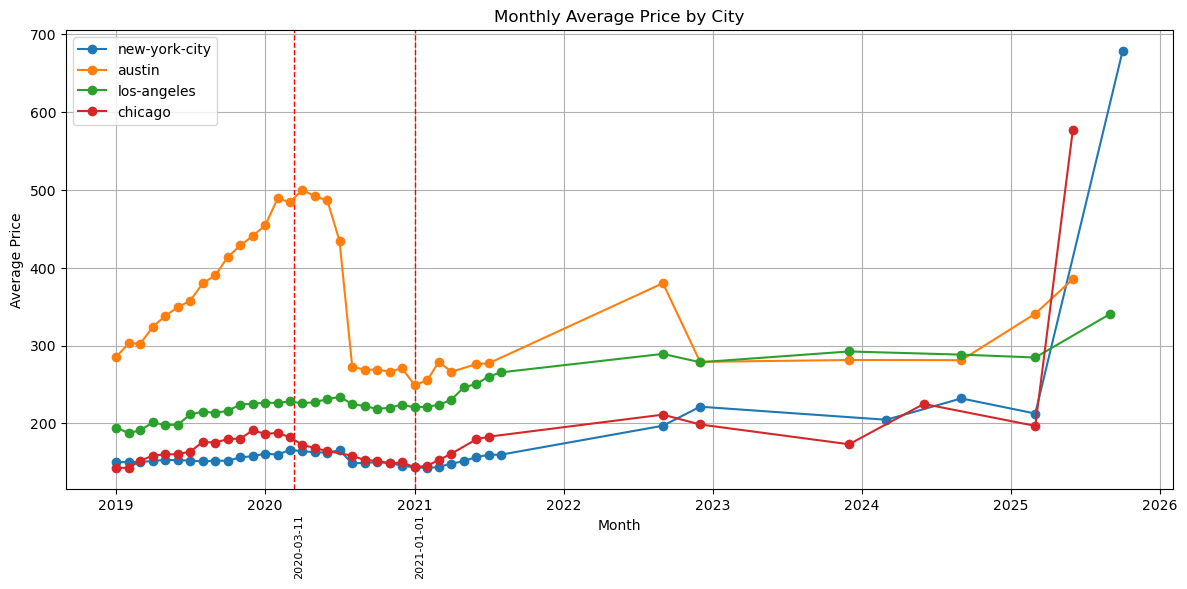

Saved figure to images/monthly_price.png

=== RUNNING DAILY: availability_365 ===

--- new-york-city ---
Files found: 83

--- austin ---
Files found: 47

--- los-angeles ---
Files found: 61

--- chicago ---
Files found: 45


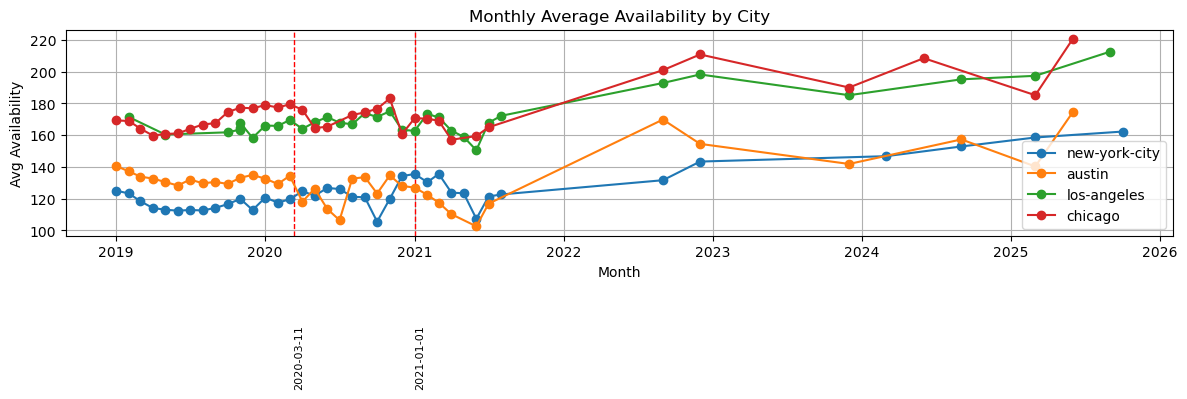

Saved figure to images/availability.png


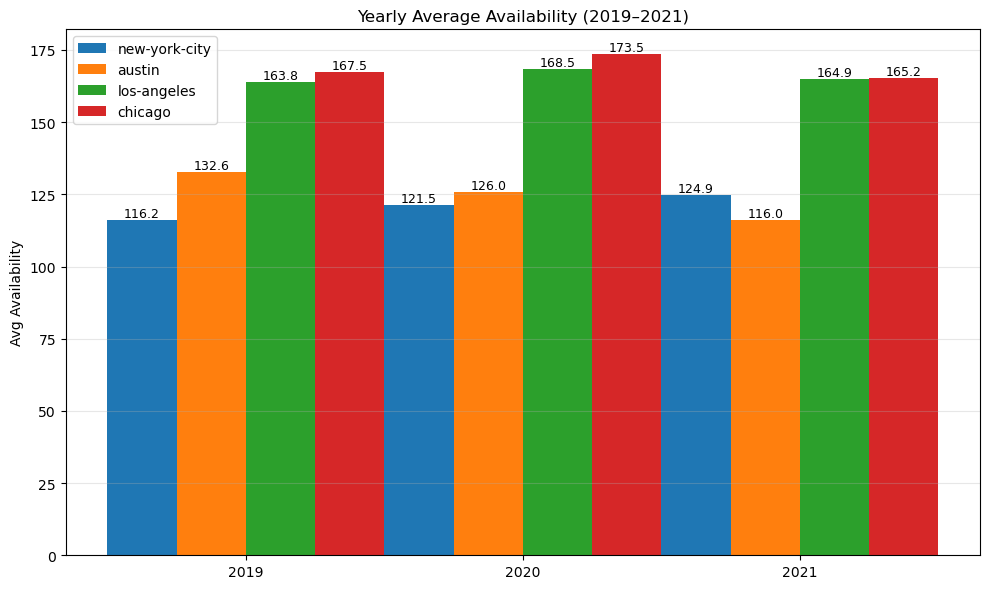

Saved bar chart to images/availability_yearly.png

=== RUNNING DAILY: calculated_host_listings_count ===

--- new-york-city ---
Files found: 83

--- austin ---
Files found: 47

--- los-angeles ---
Files found: 61

--- chicago ---
Files found: 45


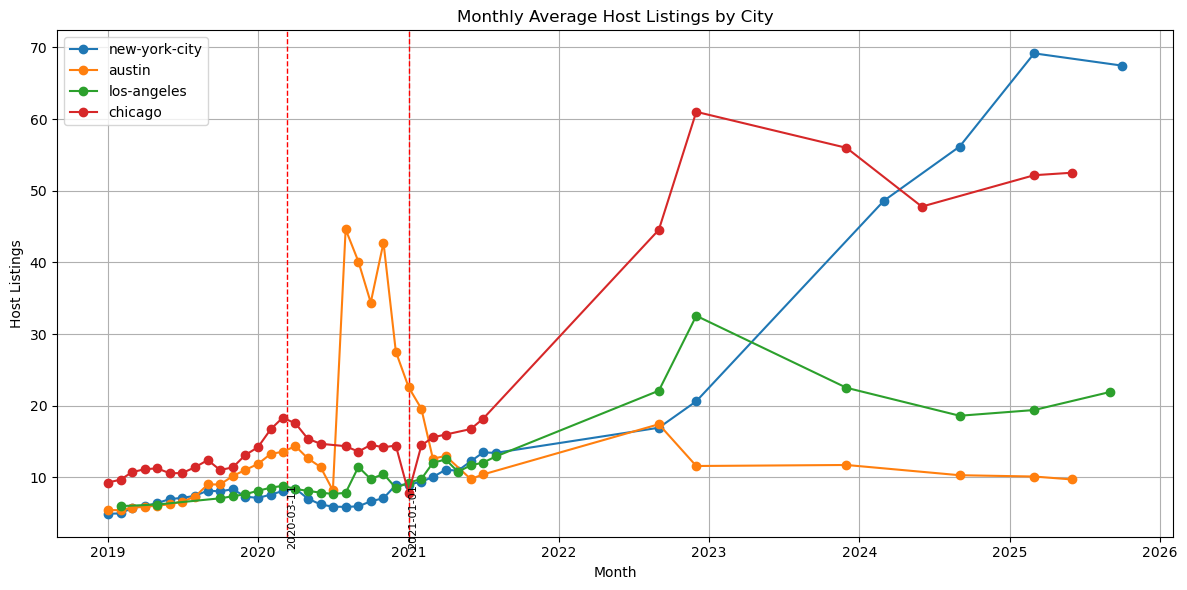

Saved figure to images/host_monthly.png


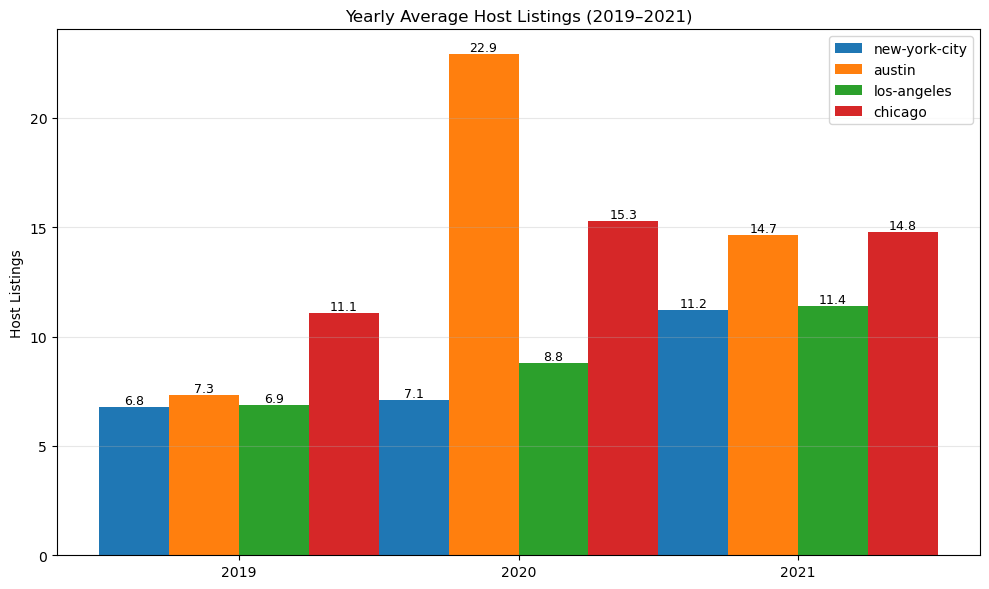

Saved bar chart to images/host_yearly.png


In [10]:
price_results = []
avail_results = []
host_results = []

PRICE_COL = "price"
AV_COL = "availability_365"
HOST_COL = "calculated_host_listings_count"

# PRICE --------------------
price_daily = collect_daily_metric(
    spark, CITY_CONFIGS, PRICE_COL, ROOT_DIR,
    START_DATE, END_DATE, is_price=True
)

for city in CITY_CONFIGS:
    df = price_daily[price_daily.city_label == city["label"]]
    monthly = aggregate_monthly(spark, df, PRICE_COL)
    price_results.append((city["label"], monthly))

plot_monthly(price_results, PRICE_COL, "Price", "Average Price", "images/monthly_price.png")


# AVAILABILITY -------------
avail_daily = collect_daily_metric(
    spark, CITY_CONFIGS, AV_COL, ROOT_DIR,
    START_DATE, END_DATE
)

for city in CITY_CONFIGS:
    df = avail_daily[avail_daily.city_label == city["label"]]
    avail_results.append((city["label"], df.drop(columns=["city_label"])))

plot_monthly(avail_results, AV_COL, "Availability", "Avg Availability", "images/availability.png")
plot_yearly(avail_results, AV_COL, "Availability", "Avg Availability", "images/availability_yearly.png")


# HOST COUNTS --------------
host_daily = collect_daily_metric(
    spark, CITY_CONFIGS, HOST_COL, ROOT_DIR,
    START_DATE, END_DATE
)

for city in CITY_CONFIGS:
    df = host_daily[host_daily.city_label == city["label"]]
    monthly = aggregate_monthly(spark, df, HOST_COL)
    host_results.append((city["label"], monthly))

plot_monthly(host_results, HOST_COL, "Host Listings", "Host Listings", "images/host_monthly.png")
plot_yearly(host_results, HOST_COL, "Host Listings", "Host Listings", "images/host_yearly.png")

spark.stop()
